# Imports

In [1]:
import os
import sys

from laboneq.simple import DeviceSetup, Session, LinearSweepParameter
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation

sys.path.append("C:\_Lib\python\clab\experiments")
import zurich_exp as zi

# Device Setup

In [2]:
# Define and Load our Device Setup
device_setup = DeviceSetup.from_yaml(
    os.getcwd() + "/helper_files/default_descriptor.yaml",
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="ZI_test",  # setup name
)
serial_num = "dev12460"
qubit_params_file_path = os.path.join(os.getcwd(), "qubit_params", "qubit_params.py")
qubit_params_module = zi.load_qubit_params(qubit_params_file_path)
lo_settings = qubit_params_module.create_lo_settings(serial_num)
los = lo_settings["q0"][serial_num]

# Are we emulating? or actually creating pulses?
emulate = True

# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.07.02 15:10:30.169] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\_Lib\python\clab\experiments\zurich_exp\test\laboneq_output\log
[2025.07.02 15:10:30.172] INFO    VERSION: laboneq 2.51.0
[2025.07.02 15:10:30.174] INFO    Connecting to data server at 127.0.0.1:8004
[2025.07.02 15:10:30.175] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.07.02 15:10:30.177] WARNING SHFQC/QA:dev12460: Include the device options 'SHFQC/QC6CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.07.02 15:10:30.178] INFO    Configuring the device setup
[2025.07.02 15:10:30.179] INFO    The device setup is configured


# Local Oscillators

In [3]:
los

{'QA0_LO': 7600000000.0,
 'SG0_LO': 4000000000.0,
 'SG2_LO': 4600000000.0,
 'SG4_LO': 1000000000.0}

# Data path

In [35]:
data_path = os.path.join(os.getcwd(), "data")
data_path

'c:\\_Lib\\python\\clab\\experiments\\zurich_exp\\test\\data'

# Run Function

In [5]:
def run(compiled_exp, data_path, file_name, simulation=False):
    if simulation:
        start = 0
        # TODO set stop to a value that makes sense for a given experiment
        stop = 5e-6
        plot_simulation(compiled_exp, start, stop)

    qubit_params_module = zi.load_qubit_params(qubit_params_file_path)
    lo_settings = qubit_params_module.create_lo_settings(serial_num)
    qubit_parameters = qubit_params_module.__dict__["qubit_parameters"]

    run_exp = session.run(compiled_exp)

    if len(run_exp.get_axis("ac_0")) == 1:
        xpts = run_exp.get_axis("ac_0")[0]
        amp = run_exp.get_data("ac_0")
        data = zi.laboneq_helper.get_dict_custom(xpts=xpts, amp=amp)
    else:
        xpts = run_exp.get_axis("ac_0")[1]
        ypts = run_exp.get_axis("ac_0")[0]
        amp = run_exp.get_data("ac_0")
        data = zi.laboneq_helper.get_dict_2D_custom(xpts=xpts, ypts=ypts, amp=amp)

    zi.laboneq_helper.save_data(
        data_path=data_path,
        file_name=file_name,
        data=data,
        config={
            "lo_settings": lo_settings,
            "qubit_parameters": qubit_parameters,
            "exp_cfg": exp_cfg,
        },
    )

# Readout Spectroscopy

## CW

[2025.07.02 15:10:30.204] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:10:30.269] INFO    Schedule completed. [0.070 s]
[2025.07.02 15:10:30.306] INFO    Code generation completed for all AWGs. [0.031 s]
[2025.07.02 15:10:30.306] INFO    Completed compilation step 1 of 1. [0.102 s]
[2025.07.02 15:10:30.313] INFO     ──────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:30.313] INFO      Device           AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:10:30.313] INFO     ──────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:30.313] INFO      SHFQC_dev12460     0         31            0           0         0  
[2025.07.02 15:10:30.313] INFO     ──────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:30.313] INFO      TOTAL                        31            0                     0  
[2025.07.02 15:10:30.316] INFO     ────────────────────────────────────────

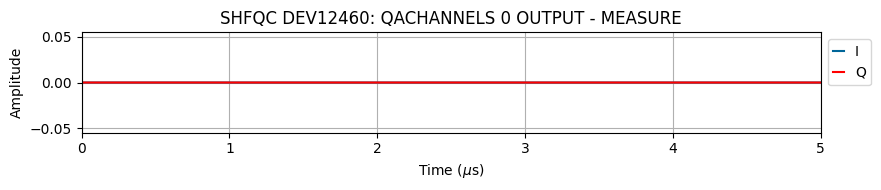

[2025.07.02 15:10:30.721] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:10:30.721] INFO    Starting near-time execution...
[2025.07.02 15:10:30.749] INFO    Estimated RT execution time: 5.06 s.
[2025.07.02 15:10:30.750] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00006_ro_res_spec_cw.h5


In [6]:
freq_swp = LinearSweepParameter(
    uid="freq_swp_param",
    start=91.75357738641754e6,
    stop=93.14126104399367e6,
    count=200,
)
exp_cfg = {
    "average_exponent": 13,
}
exp = zi.resonator_spectroscopy_cw(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    freq_swp=freq_swp,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python and communication overheads"
)

filename = "ro_res_spec_cw"
run(compiled_exp, data_path, filename, simulation=True)

## Pulsed

### 1D

[2025.07.02 15:10:30.770] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:10:30.774] INFO    Schedule completed. [0.006 s]
[2025.07.02 15:10:30.801] INFO    Code generation completed for all AWGs. [0.022 s]
[2025.07.02 15:10:30.801] INFO    Completed compilation step 1 of 1. [0.030 s]
[2025.07.02 15:10:30.803] INFO     ──────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:30.803] INFO      Device           AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:10:30.804] INFO     ──────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:30.804] INFO      SHFQC_dev12460     0         31            0           1      8000  
[2025.07.02 15:10:30.804] INFO     ──────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:30.805] INFO      TOTAL                        31            0                  8000  
[2025.07.02 15:10:30.805] INFO     ────────────────────────────────────────

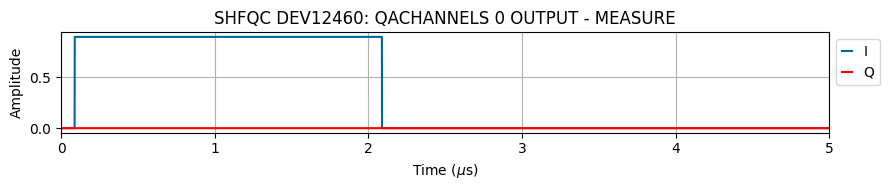

[2025.07.02 15:10:30.893] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:10:30.894] INFO    Starting near-time execution...
[2025.07.02 15:10:30.914] INFO    Estimated RT execution time: 5.00 s.
[2025.07.02 15:10:30.914] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00028_ro_res_spec.h5


In [7]:
exp_cfg = {
    "average_exponent": 12,
}
freq_swp = LinearSweepParameter(uid="freq_swp_param", start=90e6, stop=95e6, count=101)
amp_swp = LinearSweepParameter(uid="amp_swp_param", start=0.9, stop=0.9, count=1)
exp = zi.resonator_spectroscopy(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    freq_swp=freq_swp,
    amp_swp=amp_swp,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "ro_res_spec"
run(compiled_exp, data_path, filename, simulation=True)

### 2D

[2025.07.02 15:10:30.933] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:10:30.940] INFO    Schedule completed. [0.007 s]
[2025.07.02 15:10:30.964] INFO    Code generation completed for all AWGs. [0.022 s]
[2025.07.02 15:10:30.965] INFO    Completed compilation step 1 of 9. [0.031 s]
[2025.07.02 15:10:30.972] INFO    Schedule completed. [0.006 s]
[2025.07.02 15:10:30.995] INFO    Code generation completed for all AWGs. [0.022 s]
[2025.07.02 15:10:30.995] INFO    Completed compilation step 2 of 9. [0.029 s]
[2025.07.02 15:10:31.001] INFO    Schedule completed. [0.006 s]
[2025.07.02 15:10:31.020] INFO    Code generation completed for all AWGs. [0.021 s]
[2025.07.02 15:10:31.020] INFO    Completed compilation step 3 of 9. [0.029 s]
[2025.07.02 15:10:31.030] INFO    Schedule completed. [0.006 s]
[2025.07.02 15:10:31.047] INFO    Code generation completed for all AWGs. [0.022 s]
[2025.07.02 15:10:31.053] INFO    Completed compilation step 4 of 9. [0.029 s]
[2025.07.02 15:10:31.057

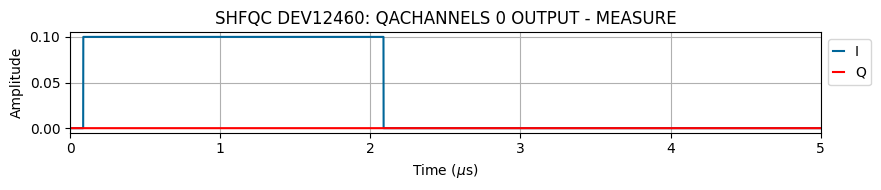

[2025.07.02 15:10:31.367] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:10:31.370] INFO    Starting near-time execution...
[2025.07.02 15:10:31.400] INFO    Estimated RT execution time: 5.00 s.
[2025.07.02 15:10:31.405] INFO    Estimated RT execution time: 5.00 s.
[2025.07.02 15:10:31.407] INFO    Estimated RT execution time: 5.00 s.
[2025.07.02 15:10:31.411] INFO    Estimated RT execution time: 5.00 s.
[2025.07.02 15:10:31.415] INFO    Estimated RT execution time: 5.00 s.
[2025.07.02 15:10:31.417] INFO    Estimated RT execution time: 5.00 s.
[2025.07.02 15:10:31.423] INFO    Estimated RT execution time: 5.00 s.
[2025.07.02 15:10:31.425] INFO    Estimated RT execution time: 5.00 s.
[2025.07.02 15:10:31.432] INFO    Estimated RT execution time: 5.00 s.
[2025.07.02 15:10:31.432] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zuri

In [8]:
exp_cfg = {
    "average_exponent": 12,
}
xpts = LinearSweepParameter(uid="xpts", start=90e6, stop=95e6, count=101)
ypts = LinearSweepParameter(uid="ypts", start=0.1, stop=0.9, count=9)
exp = zi.resonator_spectroscopy(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    freq_swp=xpts,
    amp_swp=ypts,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "ro_res_spec_2D"
run(compiled_exp, data_path, filename, simulation=True)

# ge Spectroscopy

## Qubit Spectroscopy

[2025.07.02 15:10:31.557] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:10:31.557] INFO    Phase reset in section 'shots' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:10:31.557] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:10:31.564] INFO    Schedule completed. [0.006 s]
[2025.07.02 15:10:31.698] INFO    Code generation completed for all AWGs. [0.132 s]
[2025.07.02 15:10:31.698] INFO    Completed compilation step 1 of 1. [0.139 s]
[2025.07.02 15:10:31.698] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:31.698] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:10:31.698] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:31.698] INFO      SHFQC_d

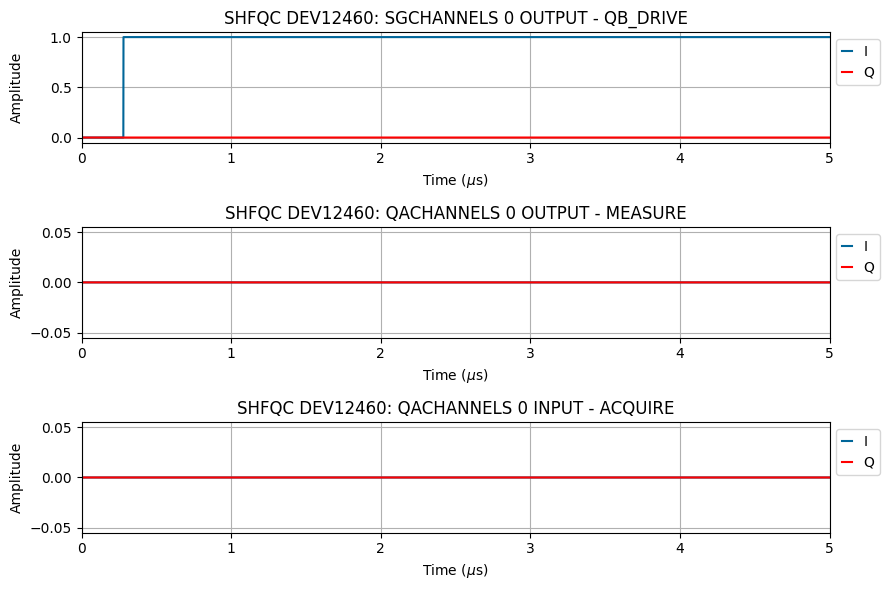

[2025.07.02 15:10:31.889] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:10:31.889] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:10:31.890] INFO    Starting near-time execution...
[2025.07.02 15:10:31.907] INFO    Estimated RT execution time: 131.79 s.
[2025.07.02 15:10:31.907] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00016_qubit_ge_spec.h5


In [14]:
freq_swp = LinearSweepParameter(uid="freq_swp_param", start=210e6, stop=215e6, count=40)
exp_cfg = {
    "average_exponent": 13,
}
exp = zi.qubit_ge_spectroscopy(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    freq_swp=freq_swp,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "qubit_ge_spec"
run(compiled_exp, data_path, filename, simulation=True)

## Length Rabi

[2025.07.02 15:10:31.927] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:10:31.927] INFO    Phase reset in section 'time_or_amp_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:10:31.931] INFO    Schedule completed. [0.007 s]
[2025.07.02 15:10:31.958] INFO    Code generation completed for all AWGs. [0.025 s]
[2025.07.02 15:10:31.958] INFO    Completed compilation step 1 of 1. [0.033 s]
[2025.07.02 15:10:31.958] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:31.958] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:10:31.958] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:31.958] INFO      SHFQC_dev12460        0        579            0           1      8000  
[2025.07.02 15:10:31.958] INFO      SHFQC_dev12460_sg     0        654           51          50

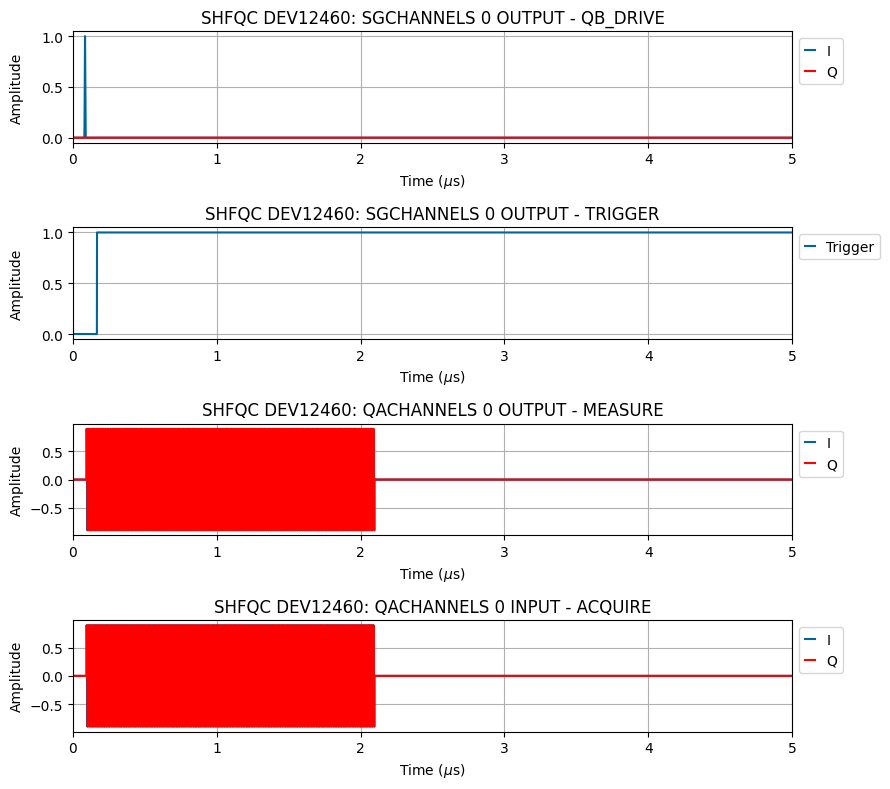

[2025.07.02 15:10:46.380] INFO    Connecting to data server at 127.0.0.1:8004
[2025.07.02 15:10:46.385] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.07.02 15:10:46.387] INFO    Configuring the device setup
[2025.07.02 15:10:46.387] INFO    The device setup is configured
[2025.07.02 15:10:46.387] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:10:46.387] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:10:46.387] INFO    Starting near-time execution...
[2025.07.02 15:10:46.407] INFO    Estimated RT execution time: 61.92 s.
[2025.07.02 15:10:46.407] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00012_len_rabi_ge.h5


In [15]:
swp_param = LinearSweepParameter(
    uid="time_swp_param", start=10e-9, stop=500e-9, count=50
)
exp_cfg = {
    "average_exponent": 12,
    "time_rabi": True,
    "pulse_type": "gaussian",
    "amplitude": 1.0,
}
exp = zi.rabi_ge(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    swp_param=swp_param,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "len_rabi_ge"
run(compiled_exp, data_path, filename, simulation=True)

In [16]:
run_exp = session.run(compiled_exp)

[2025.07.02 15:10:46.427] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:10:46.427] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:10:46.430] INFO    Starting near-time execution...
[2025.07.02 15:10:46.457] INFO    Estimated RT execution time: 61.92 s.
[2025.07.02 15:10:46.458] INFO    Finished near-time execution.


In [17]:
run_exp.experiment.uid

'rabi_ge'

## Amplitude Rabi

[2025.07.02 15:10:46.475] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:10:46.475] INFO    Phase reset in section 'time_or_amp_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:10:46.488] INFO    Schedule completed. [0.004 s]
[2025.07.02 15:10:46.633] INFO    Code generation completed for all AWGs. [0.146 s]
[2025.07.02 15:10:46.633] INFO    Completed compilation step 1 of 1. [0.151 s]
[2025.07.02 15:10:46.637] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:46.637] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:10:46.637] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:46.637] INFO      SHFQC_dev12460        0         16            0           1      8000  
[2025.07.02 15:10:46.637] INFO      SHFQC_dev12460_sg     0        351           32           2

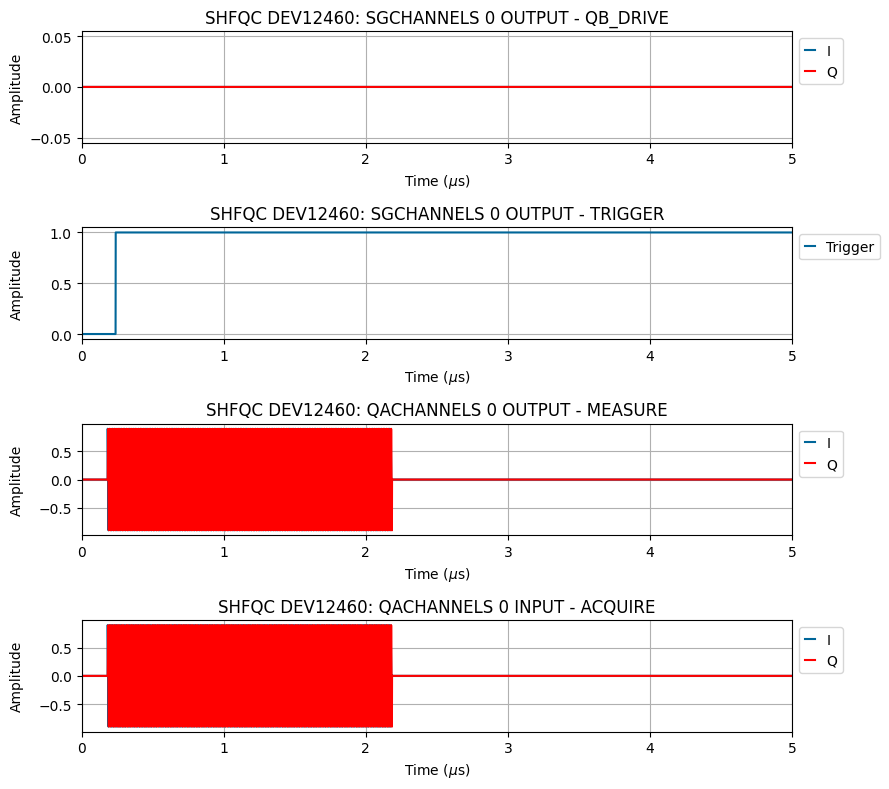

[2025.07.02 15:10:51.729] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:10:51.729] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:10:51.729] INFO    Starting near-time execution...
[2025.07.02 15:10:51.752] INFO    Estimated RT execution time: 38.37 s.
[2025.07.02 15:10:51.752] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00038_amp_rabi_ge.h5


In [18]:
swp_param = LinearSweepParameter(uid="amp_swp_param", start=0.0, stop=1.0, count=31)
exp_cfg = {
    "average_exponent": 12,
    "amplitude_rabi": True,
    "pulse_type": "const",
}
exp = zi.rabi_ge(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    swp_param=swp_param,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "amp_rabi_ge"
run(compiled_exp, data_path, filename, simulation=True)

## T1

[2025.07.02 15:10:51.770] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:10:51.772] INFO    Phase reset in section 'time_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:10:51.777] INFO    Schedule completed. [0.007 s]
[2025.07.02 15:10:51.797] INFO    Code generation completed for all AWGs. [0.021 s]
[2025.07.02 15:10:51.797] INFO    Completed compilation step 1 of 1. [0.030 s]
[2025.07.02 15:10:51.803] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:51.803] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:10:51.803] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:10:51.805] INFO      SHFQC_dev12460        0        399            0           1      8000  
[2025.07.02 15:10:51.805] INFO      SHFQC_dev12460_sg     0        329            2           1       

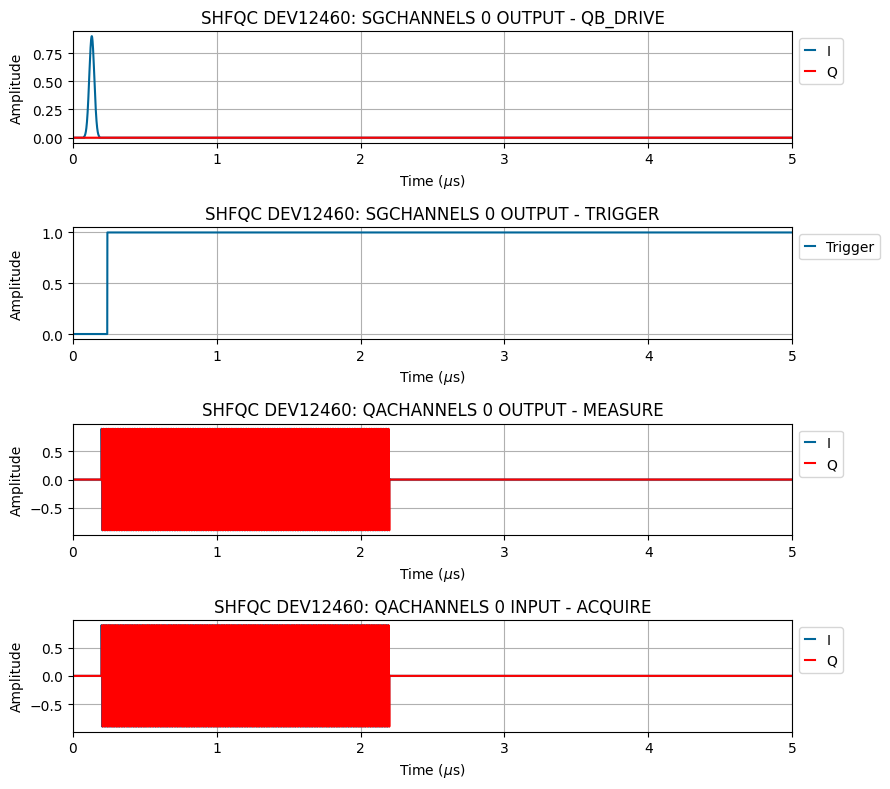

[2025.07.02 15:11:01.331] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:11:01.331] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:11:01.331] INFO    Starting near-time execution...
[2025.07.02 15:11:01.336] INFO    Estimated RT execution time: 117.28 s.
[2025.07.02 15:11:01.336] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00004_t1_e.h5


In [19]:
time_swp = LinearSweepParameter(
    uid="time_swp_param", start=10e-9, stop=350e-6, count=30
)
exp_cfg = {
    "average_exponent": 13,
}
exp = zi.t1_e(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    time_swp=time_swp,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "t1_e"
run(compiled_exp, data_path, filename, simulation=True)

## Ramsey

[2025.07.02 15:11:01.357] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:11:01.357] INFO    Phase reset in section 'time_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:11:01.362] INFO    Schedule completed. [0.007 s]
[2025.07.02 15:11:01.396] INFO    Code generation completed for all AWGs. [0.029 s]
[2025.07.02 15:11:01.396] INFO    Completed compilation step 1 of 1. [0.038 s]
[2025.07.02 15:11:01.399] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:11:01.399] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:11:01.402] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:11:01.402] INFO      SHFQC_dev12460        0        655            0           1      8000  
[2025.07.02 15:11:01.403] INFO      SHFQC_dev12460_sg     0        942           51          50     22

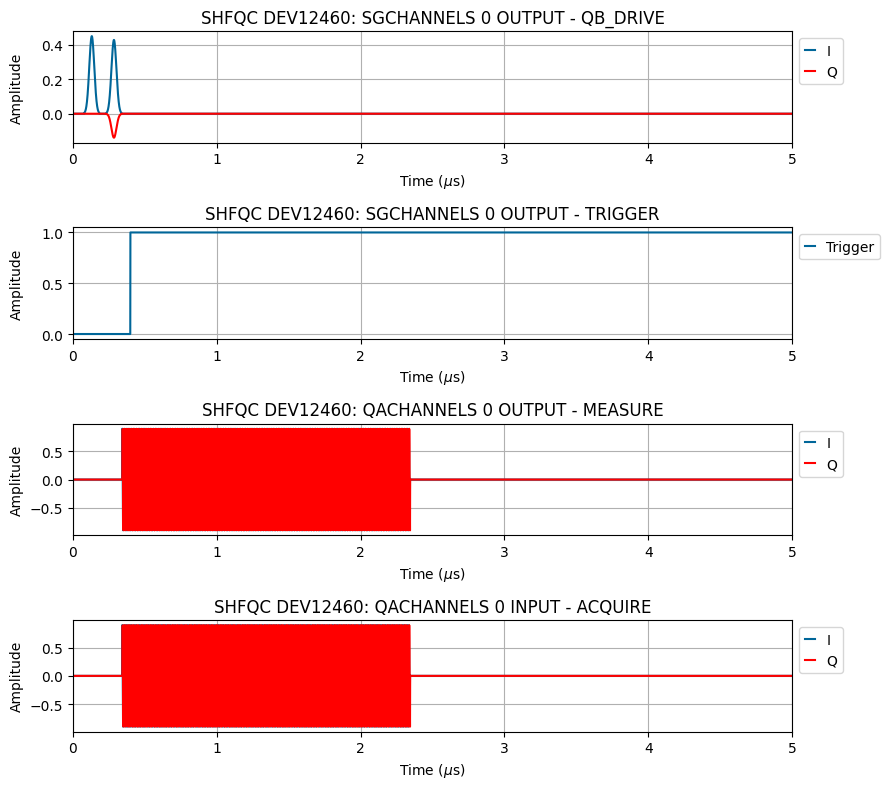

[2025.07.02 15:11:41.962] INFO    Connecting to data server at 127.0.0.1:8004
[2025.07.02 15:11:41.962] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.07.02 15:11:41.963] INFO    Configuring the device setup
[2025.07.02 15:11:41.964] INFO    The device setup is configured
[2025.07.02 15:11:41.967] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:11:41.967] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:11:41.968] INFO    Starting near-time execution...
[2025.07.02 15:11:41.989] INFO    Estimated RT execution time: 124.86 s.
[2025.07.02 15:11:41.990] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00008_ramsey_ge.h5


In [20]:
xpts = LinearSweepParameter(uid="xpts", start=50e-9, stop=5e-6, count=50)
exp_cfg = {
    "average_exponent": 13,
    "sw_detuning_freq": 1e6,
}
exp = zi.ramsey_ge(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    time_swp=xpts,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "ramsey_ge"
run(compiled_exp, data_path, filename, simulation=True)

# ef Spectroscopy

## Qubit Spectroscopy

[2025.07.02 15:12:56.575] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:12:56.575] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:12:56.575] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:12:56.602] INFO    Schedule completed. [0.026 s]
[2025.07.02 15:12:56.690] INFO    Code generation completed for all AWGs. [0.083 s]
[2025.07.02 15:12:56.690] INFO    Completed compilation step 1 of 1. [0.111 s]
[2025.07.02 15:12:56.692] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:12:56.693] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:12:56.693] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:12:56.694] INFO      S

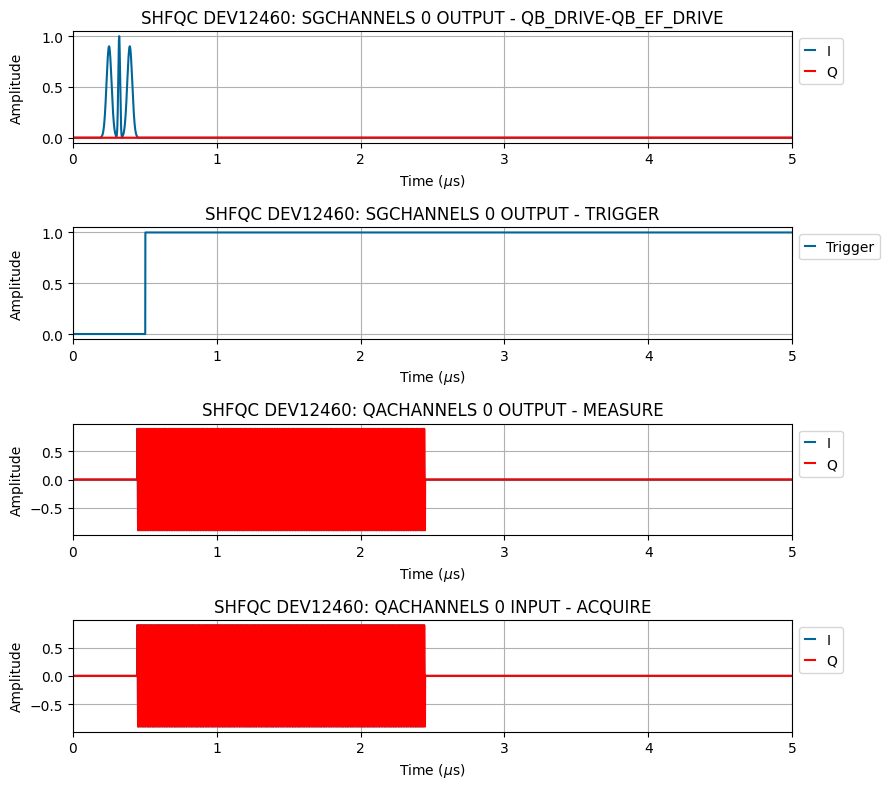

[2025.07.02 15:12:56.967] INFO    Connecting to data server at 127.0.0.1:8004
[2025.07.02 15:12:56.967] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.07.02 15:12:56.967] INFO    Configuring the device setup
[2025.07.02 15:12:56.967] INFO    The device setup is configured
[2025.07.02 15:12:56.967] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:12:56.977] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:12:56.977] INFO    Starting near-time execution...
[2025.07.02 15:12:56.994] INFO    Estimated RT execution time: 111.51 s.
[2025.07.02 15:12:56.994] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00004_qubit_ef_spec.h5


In [22]:
freq_swp = LinearSweepParameter(uid="freq_swp_param", start=45e6, stop=165e6, count=180)
exp_cfg = {
    "average_exponent": 11,
}
exp = zi.qubit_ef_spectroscopy(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    freq_swp=freq_swp,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "qubit_ef_spec"
run(compiled_exp, data_path, filename, simulation=True)

## Length Rabi

[2025.07.02 15:13:03.458] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:13:03.460] INFO    Phase reset in section 'time_or_amp_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:13:03.461] INFO    Phase reset in section 'time_or_amp_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:13:03.467] INFO    Schedule completed. [0.010 s]
[2025.07.02 15:13:03.612] INFO    Code generation completed for all AWGs. [0.143 s]
[2025.07.02 15:13:03.612] INFO    Completed compilation step 1 of 1. [0.154 s]
[2025.07.02 15:13:03.615] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:03.617] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:13:03.617] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:03.617]

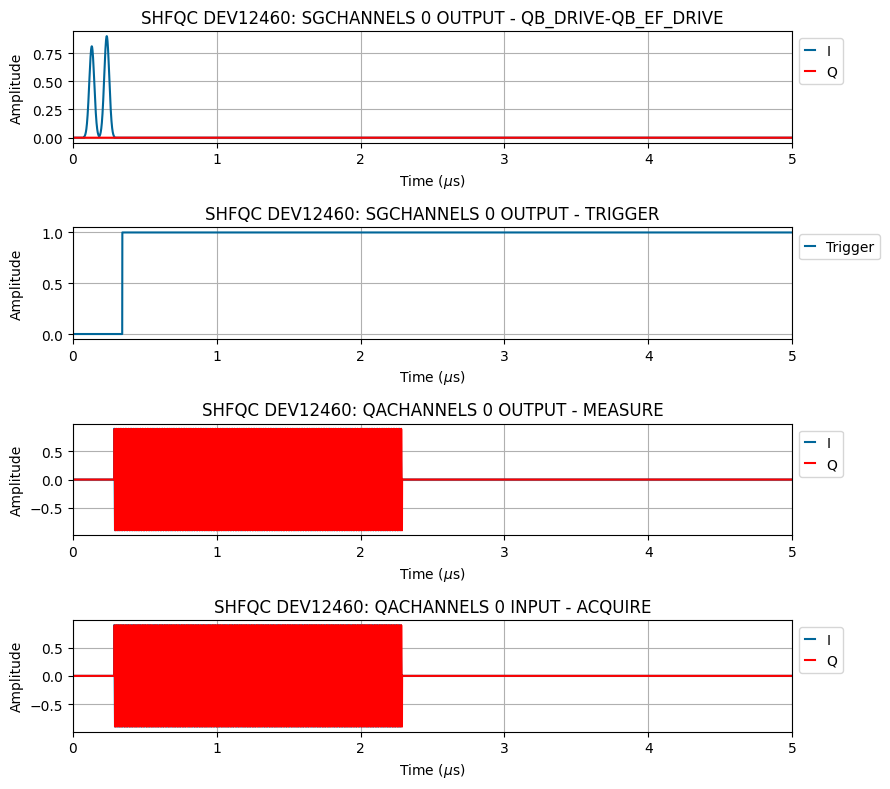

[2025.07.02 15:13:04.001] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:13:04.004] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:13:04.004] INFO    Starting near-time execution...
[2025.07.02 15:13:04.031] INFO    Estimated RT execution time: 126.42 s.
[2025.07.02 15:13:04.032] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00002_len_rabi_ef.h5


In [23]:
swp_param = LinearSweepParameter(uid="time_swp_param", start=0, stop=30e-6, count=50)
exp_cfg = {
    "average_exponent": 12,
    "time_rabi": True,
    "pulse_type": "const",
    "play_ge": True,
}
exp = zi.rabi_ef(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    swp_param=swp_param,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "len_rabi_ef"
run(compiled_exp, data_path, filename, simulation=True)

## Amplitude Rabi

[2025.07.02 15:13:10.098] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:13:10.100] INFO    Phase reset in section 'time_or_amp_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:13:10.101] INFO    Phase reset in section 'time_or_amp_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:13:10.103] INFO    Schedule completed. [0.007 s]
[2025.07.02 15:13:10.127] INFO    Requested to compress pulse(s) ef_X180_pulse which has(have) either no, or too short, constant sections. Skipping compression
[2025.07.02 15:13:10.127] INFO    Requested to compress pulse(s) ef_X180_pulse which has(have) either no, or too short, constant sections. Skipping compression
[2025.07.02 15:13:10.130] INFO    Requested to compress pulse(s) ef_X180_pulse which has(have) either no, or too short, constant sections. Skipping compression
[2025.07.02 15:13:10.131] INFO  

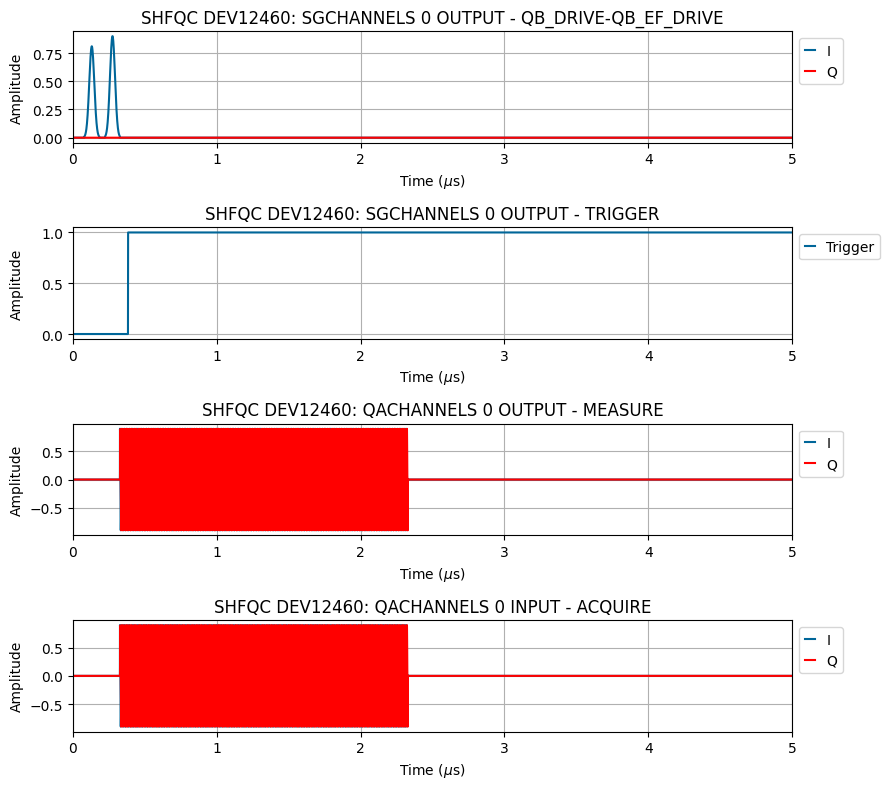

[2025.07.02 15:13:10.525] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:13:10.525] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:13:10.525] INFO    Starting near-time execution...
[2025.07.02 15:13:10.559] INFO    Estimated RT execution time: 296.07 s.
[2025.07.02 15:13:10.560] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00002_amp_rabi_ef.h5


In [24]:
swp_param = LinearSweepParameter(uid="amp_swp_param", start=0.0, stop=1.0, count=30)
exp_cfg = {
    "average_exponent": 14,
    "amplitude_rabi": True,
    "pulse_type": "const",
    "play_ge": True,
}
exp = zi.rabi_ef(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    swp_param=swp_param,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "amp_rabi_ef"
run(compiled_exp, data_path, filename, simulation=True)

## Ramsey

[2025.07.02 15:13:19.345] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:13:19.345] INFO    Schedule completed. [0.006 s]
[2025.07.02 15:13:19.386] INFO    Code generation completed for all AWGs. [0.036 s]
[2025.07.02 15:13:19.390] INFO    Completed compilation step 1 of 1. [0.043 s]
[2025.07.02 15:13:19.393] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:19.393] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:13:19.393] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:19.393] INFO      SHFQC_dev12460        0        770            0           1      8000  
[2025.07.02 15:13:19.393] INFO      SHFQC_dev12460_sg     0       1026           54          53      9696  
[2025.07.02 15:13:19.393] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:19.393] INFO      TOTAL                

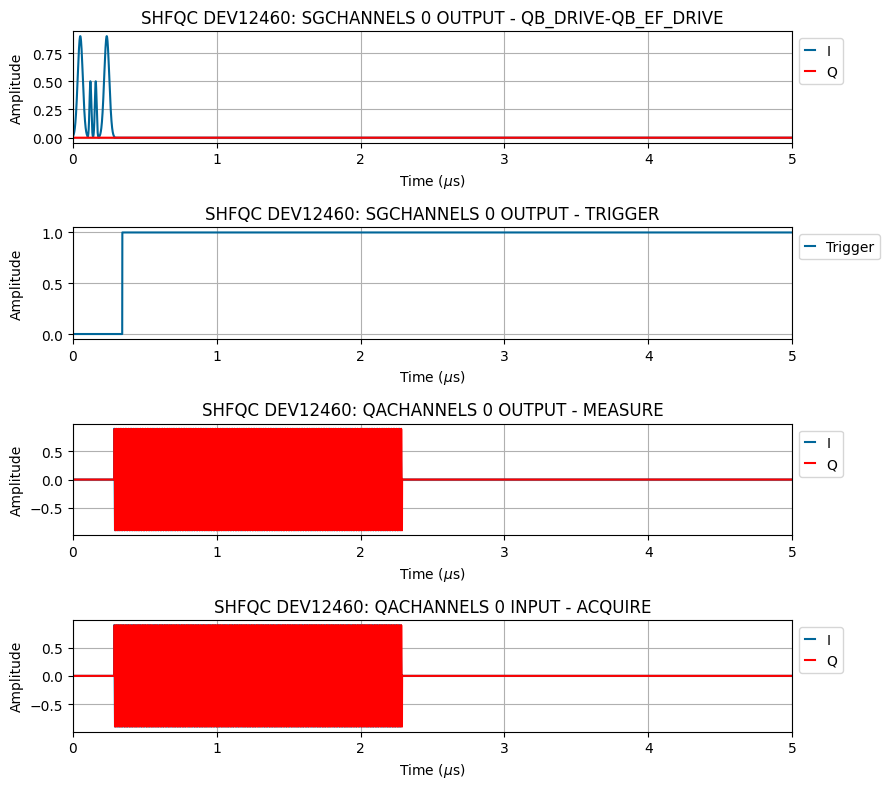

[2025.07.02 15:13:19.707] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:13:19.707] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:13:19.717] INFO    Starting near-time execution...
[2025.07.02 15:13:19.737] INFO    Estimated RT execution time: 127.59 s.
[2025.07.02 15:13:19.739] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00002_ramsey_ef.h5


In [25]:
time_swp = LinearSweepParameter(uid="time_swp", start=0, stop=17e-6, count=51)
exp_cfg = {
    "average_exponent": 12,
    "sw_detuning_freq": 0.25e6,
}
exp = zi.ramsey_ef(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    time_swp=time_swp,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "ramsey_ef"
run(compiled_exp, data_path, filename, simulation=True)

# Cavity Spectroscopy

## Resolved Length Rabi

[2025.07.02 15:13:40.230] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:13:40.233] INFO    Phase reset in section 'time_or_amp_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:13:40.244] INFO    Schedule completed. [0.011 s]
[2025.07.02 15:13:40.409] INFO    Requested to compress pulse(s) ge_X180_pulse which has(have) either no, or too short, constant sections. Skipping compression
[2025.07.02 15:13:40.603] INFO    Code generation completed for all AWGs. [0.361 s]
[2025.07.02 15:13:40.603] INFO    Completed compilation step 1 of 1. [0.374 s]
[2025.07.02 15:13:40.609] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:40.609] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:13:40.611] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:40.611] INFO      SHFQC_d

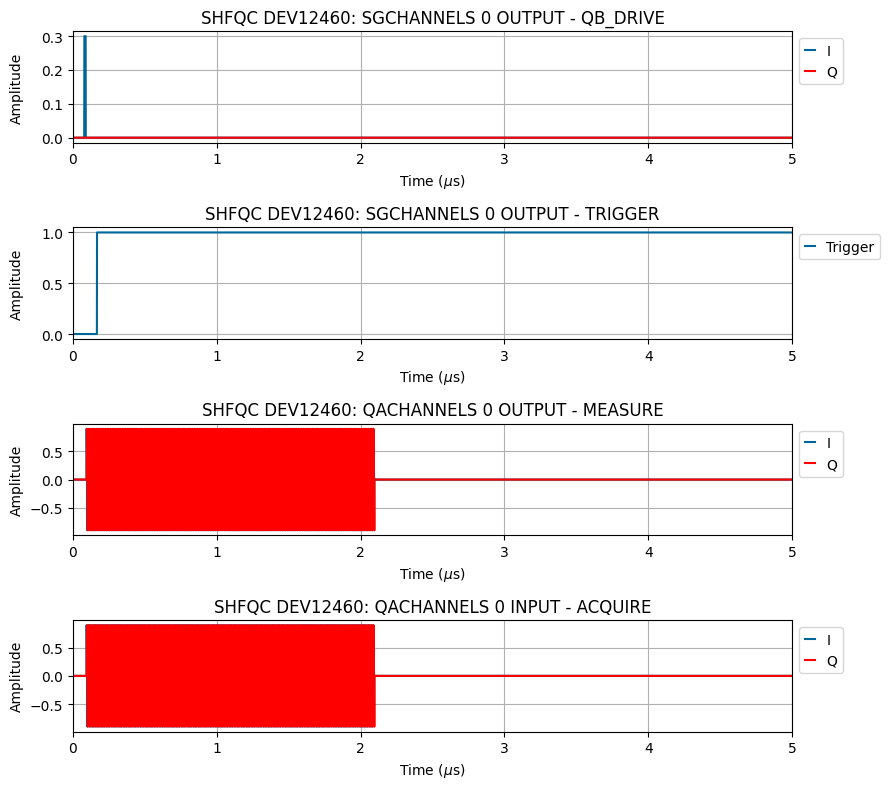

[2025.07.02 15:13:41.015] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:13:41.015] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:13:41.016] INFO    Starting near-time execution...
[2025.07.02 15:13:41.048] INFO    Estimated RT execution time: 403.74 s.
[2025.07.02 15:13:41.049] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00002_resolved_len_rabi.h5


In [27]:
swp_param = LinearSweepParameter(
    uid="time_swp_param", start=10e-9, stop=60e-6, count=80
)
exp_cfg = {
    "average_exponent": 12,
    "time_rabi": True,
    "pulse_type": "const",
    "amplitude": 0.3,
    "use_cavity_reset_delay": True,
}
exp = zi.resolved_rabi(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    swp_param=swp_param,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "resolved_len_rabi"
run(compiled_exp, data_path, filename, simulation=True)

## Resolved Amplitude Rabi

[2025.07.02 15:13:45.986] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:13:45.988] INFO    Phase reset in section 'time_or_amp_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:13:45.988] INFO    Schedule completed. [0.004 s]
[2025.07.02 15:13:46.051] INFO    Code generation completed for all AWGs. [0.059 s]
[2025.07.02 15:13:46.051] INFO    Completed compilation step 1 of 1. [0.064 s]
[2025.07.02 15:13:46.052] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:46.054] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:13:46.054] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:46.054] INFO      SHFQC_dev12460        0         22            0           1      8000  
[2025.07.02 15:13:46.054] INFO      SHFQC_dev12460_sg     0        450           63           4

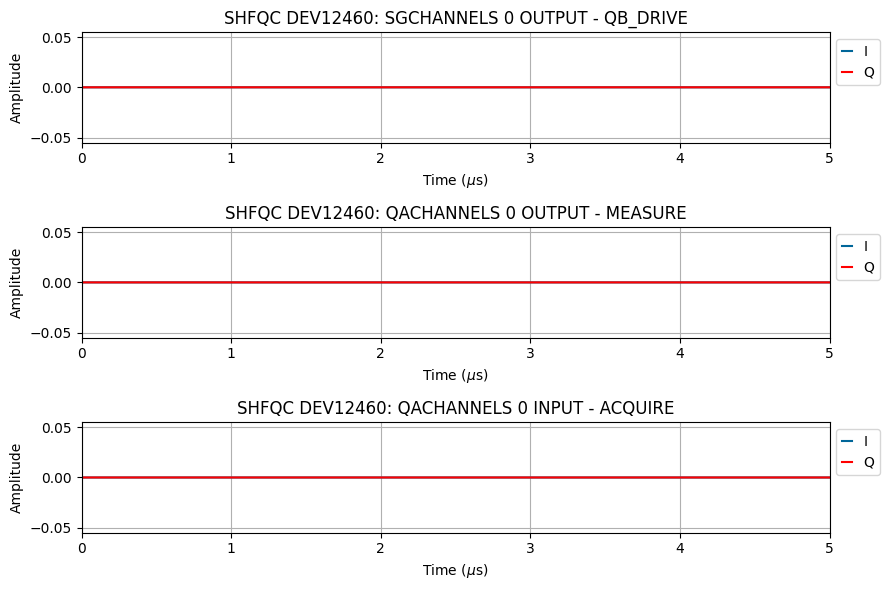

[2025.07.02 15:13:46.246] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:13:46.247] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:13:46.247] INFO    Starting near-time execution...
[2025.07.02 15:13:46.276] INFO    Estimated RT execution time: 154.21 s.
[2025.07.02 15:13:46.279] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00002_resolved_amp_rabi.h5


In [28]:
swp_param = LinearSweepParameter(uid="amp_swp_param", start=0.0, stop=1.0, count=31)
exp_cfg = {
    "average_exponent": 12,
    "amplitude_rabi": True,
    "pulse_type": "const",
    "use_cavity_reset_delay": True,
}
exp = zi.resolved_rabi(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    swp_param=swp_param,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "resolved_amp_rabi"
run(compiled_exp, data_path, filename, simulation=True)

## Cavity Spectroscopy with resolved pi pulse

[2025.07.02 15:13:53.074] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:13:53.076] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:13:53.076] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:13:53.082] INFO    Schedule completed. [0.006 s]
[2025.07.02 15:13:53.176] INFO    Code generation completed for all AWGs. [0.097 s]
[2025.07.02 15:13:53.176] INFO    Completed compilation step 1 of 1. [0.105 s]
[2025.07.02 15:13:53.176] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:53.176] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:13:53.176] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:13:53.176] INFO      S

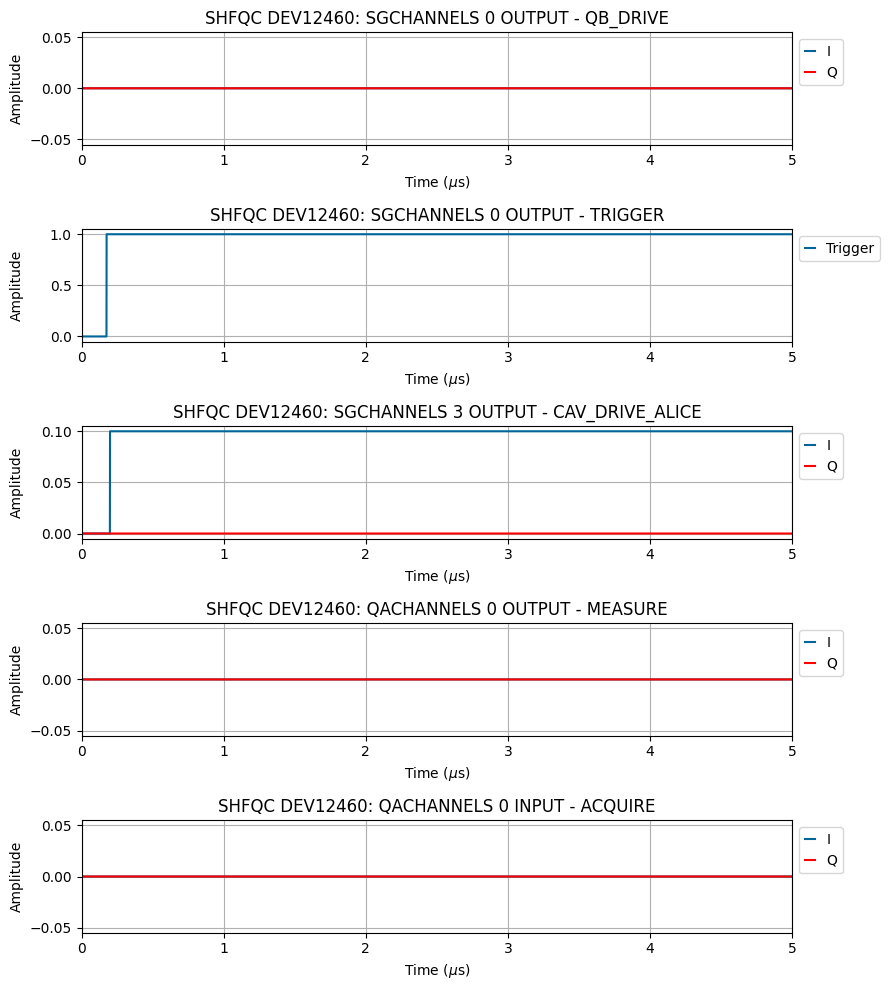

[2025.07.02 15:13:53.492] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:13:53.497] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:13:53.497] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:13:53.497] INFO    Starting near-time execution...
[2025.07.02 15:13:53.520] INFO    Estimated RT execution time: 202.28 s.
[2025.07.02 15:13:53.522] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00001_cav_spec_alice.h5


In [ ]:
freq_swp = LinearSweepParameter(
    uid="freq_swp_param", start=-330e6, stop=-329.5e6, count=40
)
exp_cfg = {
    "average_exponent": 12,
}
exp = zi.cavity_spectroscopy(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    freq_swp=freq_swp,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "cav_spec"
run(compiled_exp, data_path, filename, simulation=True)

## PNRQS

cav_line: cav_drive_alice
[2025.07.02 15:14:18.721] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:14:18.721] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:14:18.721] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:14:18.729] INFO    Schedule completed. [0.006 s]
[2025.07.02 15:14:18.819] INFO    Code generation completed for all AWGs. [0.097 s]
[2025.07.02 15:14:18.819] INFO    Completed compilation step 1 of 1. [0.104 s]
[2025.07.02 15:14:18.829] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:14:18.829] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:14:18.829] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02

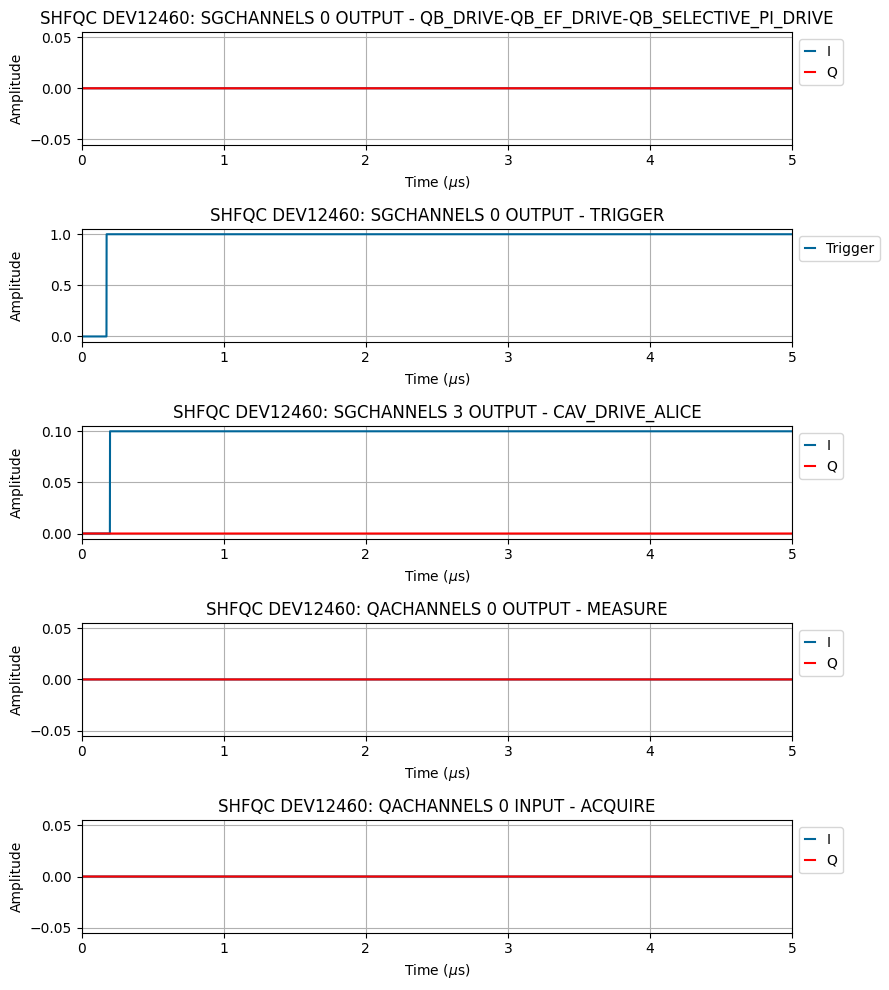

[2025.07.02 15:14:19.150] INFO    Connecting to data server at 127.0.0.1:8004
[2025.07.02 15:14:19.154] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.07.02 15:14:19.154] INFO    Configuring the device setup
[2025.07.02 15:14:19.154] INFO    The device setup is configured
[2025.07.02 15:14:19.154] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:14:19.154] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:14:19.160] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:14:19.160] INFO    Starting near-time execution...
[2025.07.02 15:14:19.175] INFO    Estimated RT execution tim

In [32]:
nu_q = (4.212876765016383 - 4) * 1e9
range = [-0.7e6, 0.3e6]
range = [nu_q + range[0], nu_q + range[1]]

freq_swp = LinearSweepParameter(
    uid="freq_swp_param", start=range[0], stop=range[1], count=40
)
exp_cfg = {
    "average_exponent": 12,
    "alice_or_bob": "alice",
    "state": 0,
}
exp = zi.pnrqs(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    freq_swp=freq_swp,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "pnrqs"
run(compiled_exp, data_path, filename, simulation=True)

## Cavity Length Rabi

[2025.07.02 15:15:38.548] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:15:38.548] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:15:38.548] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:15:38.552] INFO    Schedule completed. [0.005 s]
[2025.07.02 15:15:38.773] INFO    Requested to compress pulse(s) cav_alice_pulse which has(have) either no, or too short, constant sections. Skipping compression
[2025.07.02 15:15:38.883] INFO    Code generation completed for all AWGs. [0.335 s]
[2025.07.02 15:15:38.883] INFO    Completed compilation step 1 of 1. [0.341 s]
[2025.07.02 15:15:38.893] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:15:38.893] INFO      Device              AWG   SeqC LOC   CT entries   Wavef

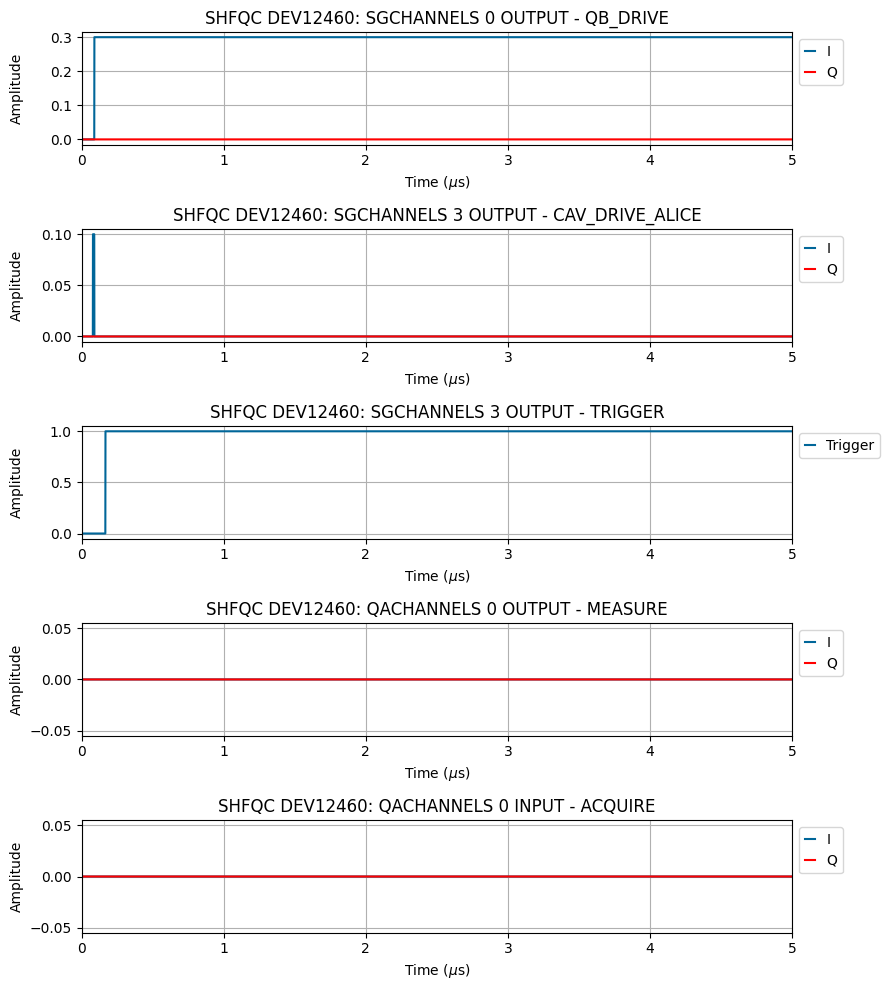

[2025.07.02 15:15:39.273] INFO    Connecting to data server at 127.0.0.1:8004
[2025.07.02 15:15:39.273] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.07.02 15:15:39.273] INFO    Configuring the device setup
[2025.07.02 15:15:39.281] INFO    The device setup is configured
[2025.07.02 15:15:39.281] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:15:39.281] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:15:39.281] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:15:39.281] INFO    Starting near-time execution...
[2025.07.02 15:15:39.300] INFO    Estimated RT execution tim

In [34]:
swp_param = LinearSweepParameter(
    uid="time_swp_param", start=0.01e-6, stop=150e-6, count=30
)
exp_cfg = {
    "average_exponent": 11,
}
exp = zi.cav_len_rabi(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    time_swp=swp_param,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "cav_len_rabi"
run(compiled_exp, data_path, filename, simulation=True)

## Cavity Rabi T1

[2025.07.02 15:16:26.944] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:16:26.944] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:16:26.944] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:16:26.953] INFO    Schedule completed. [0.006 s]
[2025.07.02 15:16:27.037] INFO    Code generation completed for all AWGs. [0.083 s]
[2025.07.02 15:16:27.037] INFO    Completed compilation step 1 of 1. [0.090 s]
[2025.07.02 15:16:27.040] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:16:27.040] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:16:27.040] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:16:27.041] INFO      S

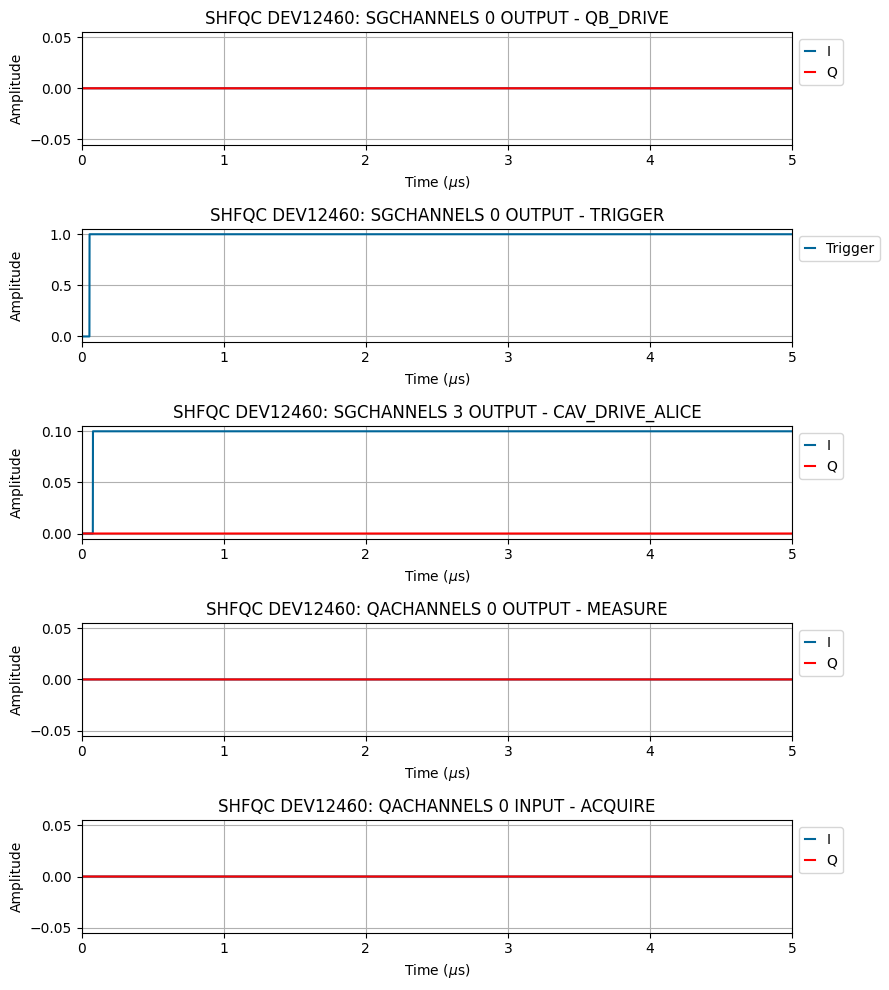

[2025.07.02 15:16:27.398] INFO    Connecting to data server at 127.0.0.1:8004
[2025.07.02 15:16:27.398] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.07.02 15:16:27.398] INFO    Configuring the device setup
[2025.07.02 15:16:27.398] INFO    The device setup is configured
[2025.07.02 15:16:27.404] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:16:27.404] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:16:27.404] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:16:27.404] INFO    Starting near-time execution...
[2025.07.02 15:16:27.420] INFO    Estimated RT execution tim

In [37]:
swp_param = LinearSweepParameter(
    uid="time_swp_param", start=0.01e-6, stop=4e-3, count=30
)
exp_cfg = {
    "average_exponent": 12,
}
exp = zi.cav_rabi_t1(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    time_swp=swp_param,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "cav_rabi_t1"
run(compiled_exp, data_path, filename, simulation=True)

# Qubit T1 rho

[2025.07.02 15:16:36.628] INFO    Starting LabOne Q Compiler run...
[2025.07.02 15:16:36.630] INFO    Phase reset in section 'time_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.07.02 15:16:36.633] INFO    Schedule completed. [0.006 s]
[2025.07.02 15:16:36.887] INFO    Code generation completed for all AWGs. [0.251 s]
[2025.07.02 15:16:36.887] INFO    Completed compilation step 1 of 1. [0.259 s]
[2025.07.02 15:16:36.891] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:16:36.891] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.07.02 15:16:36.891] INFO     ─────────────────────────────────────────────────────────────────────── 
[2025.07.02 15:16:36.891] INFO      SHFQC_dev12460        0        655            0           1      8000  
[2025.07.02 15:16:36.891] INFO      SHFQC_dev12460_sg     0        807           52          51     26

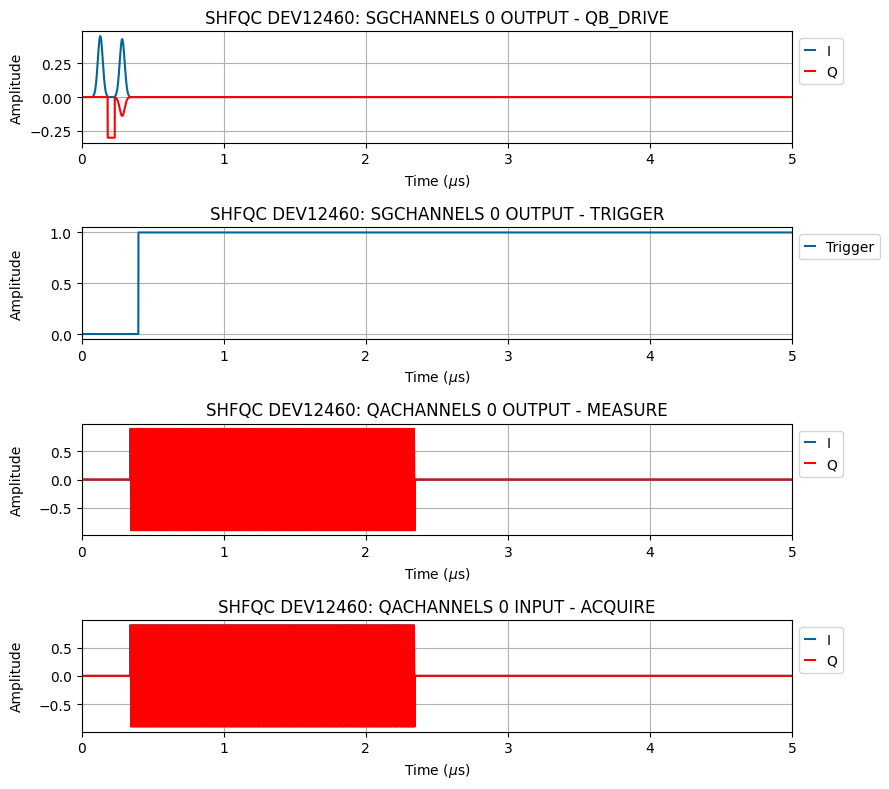

[2025.07.02 15:17:19.566] INFO    Connecting to data server at 127.0.0.1:8004
[2025.07.02 15:17:19.567] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.07.02 15:17:19.568] INFO    Configuring the device setup
[2025.07.02 15:17:19.569] INFO    The device setup is configured
[2025.07.02 15:17:19.570] WARNING SHFQC/QA:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no muting will happen. It is suggested to disable it.
[2025.07.02 15:17:19.570] WARNING SHFQC/SG:dev12460: Device output muting is enabled, but the device is not SHF+ and therefore no mutting will happen. It is suggested to disable it.
[2025.07.02 15:17:19.570] INFO    Starting near-time execution...
[2025.07.02 15:17:19.586] INFO    Estimated RT execution time: 124.86 s.
[2025.07.02 15:17:19.586] INFO    Finished near-time execution.
File saved at c:\_Lib\python\clab\experiments\zurich_exp\test\data\00001_qubit_t1_rho.h5


In [38]:
time_swp = LinearSweepParameter(uid="time_swp_param", start=50e-9, stop=5e-6, count=50)
exp_cfg = {
    "average_exponent": 13,
    "sw_detuning_freq": 1e6,
}
exp = zi.qubit_t1_rho(
    device_setup=device_setup,
    serial_num=serial_num,
    qubit_params_file_path=qubit_params_file_path,
    time_swp=time_swp,
    **exp_cfg,
)
compiled_exp = session.compile(exp)

print(
    f"{compiled_exp.estimated_runtime}s estimated runtime, excluding python, communication, and near-time operations overheads"
)

filename = "qubit_t1_rho"
run(compiled_exp, data_path, filename, simulation=True)